# Семинар 1: знакомство с PyTorch

От операций с тензорами до обучения и сохранения первой нейросети.

## Подготовка и запуск

Используйте Python 3.11+ и совместимые версии PyTorch / torchvision. Для установки в терминале:

```bash
python -m pip install torch torchvision numpy matplotlib jupyterlab
python -m jupyterlab
```

В уже открытом ноутбуке можно выполнить `%pip install torch torchvision numpy matplotlib`
в отдельной ячейке и перезапустить ядро. Для CUDA выберите команду в
[официальном установщике PyTorch](https://pytorch.org/get-started/locally/).
Установка пакетов не выполняется автоматически при Run All.

При первом запуске MNIST скачивается в `./data` (нужен интернет), затем используется кеш.
Графики строятся локально; аккаунты и API-ключи не нужны. Вес модели сохраняется в `./artifacts`.

In [ ]:
import os
import platform
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
from torch import nn
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split

%matplotlib inline

SEED = 42
QUICK_RUN = True
DEVICE = os.environ.get("PYTORCH_SEMINAR_DEVICE", "cpu")
DATA_DIR = Path("data")
ARTIFACT_DIR = Path("artifacts")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
# На маленьких матрицах слишком много CPU-потоков замедляет вычисления.
torch.set_num_threads(min(4, os.cpu_count() or 1))
if DEVICE == "auto":
    DEVICE = ("cuda" if torch.cuda.is_available() else
              "mps" if torch.backends.mps.is_available() else "cpu")
device = torch.device(DEVICE)
print(f"Python {platform.python_version()} | PyTorch {torch.__version__}")
print(f"torchvision {torchvision.__version__} | NumPy {np.__version__}")
print(f"device={device}, quick_run={QUICK_RUN}, seed={SEED}")
print("Проверка устройства:", torch.ones(1, device=device))


Python 3.13.15 | PyTorch 2.11.0+cu128
torchvision 0.26.0+cu128 | NumPy 2.1.3
device=cuda, quick_run=True, seed=42
Проверка устройства: tensor([1.], device='cuda:0')


Фиксация seed помогает повторить эксперимент в одном окружении. Она не гарантирует побитового
совпадения между версиями библиотек и CPU / CUDA / MPS. Учебные операции с тензорами ниже
выполняются на CPU, а классификатор переносится на выбранное устройство.


## 1. NumPy и PyTorch

Тензор - многомерный массив. Сравним создание, арифметику, редукции и изменение формы.


In [ ]:
# случайная матрица
a = np.random.rand(5, 3)
a


array([[0.37454012, 0.95071431, 0.73199394],
       [0.59865848, 0.15601864, 0.15599452],
       [0.05808361, 0.86617615, 0.60111501],
       [0.70807258, 0.02058449, 0.96990985],
       [0.83244264, 0.21233911, 0.18182497]])

In [ ]:
# размеры массива
a.shape


(5, 3)

In [ ]:
# сложение
a + 5


array([[5.37454012, 5.95071431, 5.73199394],
       [5.59865848, 5.15601864, 5.15599452],
       [5.05808361, 5.86617615, 5.60111501],
       [5.70807258, 5.02058449, 5.96990985],
       [5.83244264, 5.21233911, 5.18182497]])

In [ ]:
# матричное умножение
a @ a.T


array([[1.57995312, 0.48673782, 1.28525324, 0.9947397 , 0.64675177],
       [0.48673782, 0.40706809, 0.26368252, 0.57840584, 0.55984141],
       [1.28525324, 0.26368252, 1.11497408, 0.64198458, 0.34157207],
       [0.9947397 , 0.57840584, 0.64198458, 1.44251562, 0.77015453],
       [0.64675177, 0.55984141, 0.34157207, 0.77015453, 0.77110897]])

In [ ]:
# Среднее по последней оси: для каждой строки получаем одно число.
a.mean(axis=-1)


array([0.68574946, 0.30355721, 0.50845826, 0.56618897, 0.40886891])

In [ ]:
# решейп
a.reshape(3, 5).shape


(3, 5)

**Разминка**

При помощи **NumPy** посчитайте сумму квадратов натуральных чисел от 1 до 10000.


In [ ]:
(np.arange(1, 10001) ** 2).sum()


np.int64(333383335000)

Аналогичные операции в **PyTorch** очень похожи, но иногда имеют немного другой синтаксис


In [ ]:
# случайный тензор
x = torch.rand(5, 3)
x


tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009],
        [0.2566, 0.7936, 0.9408],
        [0.1332, 0.9346, 0.5936],
        [0.8694, 0.5677, 0.7411]])

In [ ]:
# размеры тензора
x.shape


torch.Size([5, 3])

In [ ]:
# тоже размеры тензора
x.size()


torch.Size([5, 3])

In [ ]:
# сложение
x + 5


tensor([[5.8823, 5.9150, 5.3829],
        [5.9593, 5.3904, 5.6009],
        [5.2566, 5.7936, 5.9408],
        [5.1332, 5.9346, 5.5936],
        [5.8694, 5.5677, 5.7411]])

In [ ]:
# матричное умножение
# читайте документации по различным вариантам: @, torch.mm, torch.matmul, torch.bmm
torch.matmul(x, x.transpose(1, 0))


tensor([[1.7622, 1.4337, 1.3127, 1.1999, 1.5702],
        [1.4337, 1.4338, 1.1213, 0.8494, 1.5010],
        [1.3127, 1.1213, 1.5807, 1.3343, 1.3708],
        [1.1999, 0.8494, 1.3343, 1.2435, 1.0863],
        [1.5702, 1.5010, 1.3708, 1.0863, 1.6274]])

In [ ]:
x @ x.T


tensor([[1.7622, 1.4337, 1.3127, 1.1999, 1.5702],
        [1.4337, 1.4338, 1.1213, 0.8494, 1.5010],
        [1.3127, 1.1213, 1.5807, 1.3343, 1.3708],
        [1.1999, 0.8494, 1.3343, 1.2435, 1.0863],
        [1.5702, 1.5010, 1.3708, 1.0863, 1.6274]])

In [ ]:
# очередное матричное умножение
x.mm(x.t())


tensor([[1.7622, 1.4337, 1.3127, 1.1999, 1.5702],
        [1.4337, 1.4338, 1.1213, 0.8494, 1.5010],
        [1.3127, 1.1213, 1.5807, 1.3343, 1.3708],
        [1.1999, 0.8494, 1.3343, 1.2435, 1.0863],
        [1.5702, 1.5010, 1.3708, 1.0863, 1.6274]])

In [ ]:
# поэлементное умножение
x * x


tensor([[0.7784, 0.8372, 0.1466],
        [0.9203, 0.1524, 0.3611],
        [0.0658, 0.6299, 0.8851],
        [0.0177, 0.8735, 0.3523],
        [0.7559, 0.3223, 0.5492]])

In [ ]:
# Среднее по последней оси (по элементам каждой строки).
x.mean(dim=-1)


tensor([0.7267, 0.6502, 0.6637, 0.5538, 0.7261])

In [ ]:
# решейп
x.view([3, 5]).shape


torch.Size([3, 5])

In [ ]:
# или так
x.reshape([3, 5]).shape


torch.Size([3, 5])

In [ ]:
# будьте внимательны и не используйте view для транспонирования осей!
x.view_as(x.t()) == x.t()


tensor([[ True, False, False, False, False],
        [False, False,  True, False, False],
        [False, False, False, False,  True]])

Аналоги NumPy: `sum(axis=...)` → `sum(dim=...)`, `astype("int64")` → `to(torch.int64)`.
`reshape` есть в обеих библиотеках. `view` — отдельная операция PyTorch с ограничениями на расположение данных в памяти.
Справочник: [операции с тензорами](https://docs.pytorch.org/docs/stable/torch.html).


Разминка на PyTorch

При помощи pytorch посчитайте сумму квадратов натуральных чисел от 1 до 10000.


In [ ]:
(torch.arange(1, 10001) ** 2).sum()


tensor(333383335000)

## 2. Тензоры: создание, формы и память


In [ ]:
# Неинициализированная память: значения empty нельзя использовать до записи!
x = torch.empty(5, 3)
x.fill_(2.0)
x


tensor([[2., 2., 2.],
        [2., 2., 2.],
        [2., 2., 2.],
        [2., 2., 2.],
        [2., 2., 2.]])

In [ ]:
# случайный тензор ~ Uniform[0, 1)
x = torch.rand(5, 3)
x


tensor([[0.4294, 0.8854, 0.5739],
        [0.2666, 0.6274, 0.2696],
        [0.4414, 0.2969, 0.8317],
        [0.1053, 0.2695, 0.3588],
        [0.1994, 0.5472, 0.0062]])

In [ ]:
# тензор с нулями и указанием типов чисел
x = torch.zeros(5, 3, dtype=torch.float32)
x


tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

In [ ]:
# конструируем тензор из питоновского листа
x = torch.tensor([5.5, 3])
x


tensor([5.5000, 3.0000])

In [ ]:
# используем уже созданный тензор для создания тензора из единичек
x1 = x.new_ones(5, 3, dtype=torch.double)
x1


tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]], dtype=torch.float64)

In [ ]:
# создаем случайный тензор с размерами другого тензора
x = torch.randn_like(x1, dtype=torch.float)
x


tensor([[-0.3267, -0.2788, -0.4220],
        [-1.3323, -0.3639,  0.1513],
        [-0.3514, -0.7906, -0.0915],
        [ 0.2352,  2.2440,  0.5817],
        [ 0.4528,  0.6410,  0.5200]])

In [ ]:
x = torch.rand(5, 3)
y = torch.rand(5, 3)


In [ ]:
x


tensor([[0.6542, 0.3278, 0.6532],
        [0.3958, 0.9147, 0.2036],
        [0.2018, 0.2018, 0.9497],
        [0.6666, 0.9811, 0.0874],
        [0.0041, 0.1088, 0.1637]])

In [ ]:
y


tensor([[0.7025, 0.6790, 0.9155],
        [0.2418, 0.1591, 0.7653],
        [0.2979, 0.8035, 0.3813],
        [0.7860, 0.1115, 0.2477],
        [0.6524, 0.6057, 0.3725]])

In [ ]:
# сложение
x + y


tensor([[1.3567, 1.0068, 1.5687],
        [0.6376, 1.0738, 0.9689],
        [0.4997, 1.0052, 1.3311],
        [1.4526, 1.0926, 0.3350],
        [0.6565, 0.7145, 0.5362]])

In [ ]:
# очередное сложение
z = torch.add(x, y)
z


tensor([[1.3567, 1.0068, 1.5687],
        [0.6376, 1.0738, 0.9689],
        [0.4997, 1.0052, 1.3311],
        [1.4526, 1.0926, 0.3350],
        [0.6565, 0.7145, 0.5362]])

In [ ]:
# out= записывает результат в существующий тензор; здесь autograd не используется.
z = torch.empty_like(x)
torch.add(x, y, out=z)
z


tensor([[1.3567, 1.0068, 1.5687],
        [0.6376, 1.0738, 0.9689],
        [0.4997, 1.0052, 1.3311],
        [1.4526, 1.0926, 0.3350],
        [0.6565, 0.7145, 0.5362]])

In [ ]:
torch.from_numpy(np.array([1, 2]))


tensor([1, 2])

In [ ]:
# Добавляем ось размера 1; broadcasting разберём отдельно.
x.unsqueeze(0).size()


torch.Size([1, 5, 3])

In [ ]:
# убрали одно единичное измерение
x.unsqueeze(0).unsqueeze(1).squeeze(0).size()


torch.Size([1, 5, 3])

In [ ]:
x.unsqueeze(1).size()


torch.Size([5, 1, 3])

In [ ]:
# Ось 2 имеет размер 3: squeeze(2) ничего не меняет.
x.unsqueeze(1).squeeze(2).size()


torch.Size([5, 1, 3])

In [ ]:
# Две новые оси размера 1.
x.unsqueeze(0).unsqueeze(1).size()


torch.Size([1, 1, 5, 3])

In [ ]:
x.unsqueeze(0).unsqueeze(1)[0][0].size()


torch.Size([5, 3])

In [ ]:
x.unsqueeze(0).unsqueeze(1).squeeze().size()


torch.Size([5, 3])

In [ ]:
# unsqueeze не меняет форму x, но результат разделяет с x память.
x.unsqueeze(0)
x.size()


torch.Size([5, 3])

In [ ]:
# Суффикс _ обычно означает изменение на месте (in-place).
x.unsqueeze_(0)
x.size()


torch.Size([1, 5, 3])

Мы можем делать обычные срезы и переводить матрицы из **PyTorch** в **NumPy** и наоборот:


In [ ]:
a = np.ones((3, 5))
x = torch.ones((3, 5))
np.allclose(x.numpy(), a)


True

In [ ]:
np.allclose(x.numpy()[:, 1], a[:, 1])


True

In [ ]:
torch.from_numpy(x.numpy())


tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]])

### 2.1. А у меня не работает :(

`shape` задаёт размеры осей, `dtype` — тип чисел, `device` — устройство.
Входы линейного слоя обычно `float32`, индексы классов — `int64` (`torch.long`).
NumPy часто создаёт `float64`; явное преобразование помогает избежать несовместимых типов.
`tensor.to(...)` возвращает результат: присваивайте его переменной.


In [ ]:
features = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float32)
labels = torch.tensor([0, 1], dtype=torch.long)
print(features.shape, features.dtype, features.device)
on_device = features.to(device)
assert on_device.dtype == torch.float32
print("На выбранном устройстве:", on_device.device)
print("Обратно в NumPy:", on_device.detach().cpu().numpy())


torch.Size([2, 3]) torch.float32 cpu
На выбранном устройстве: cpu
Обратно в NumPy: [[1. 2. 3.]
 [4. 5. 6.]]


### 2.2. Общая память и копии

`torch.tensor(array)` копирует данные; `torch.from_numpy(array)` разделяет память с поддерживаемым
NumPy-массивом. Срезы, `transpose` и `unsqueeze` тоже могут разделять память.
Отсутствие `_` **не означает**, что данные скопированы. Для независимой копии нужен `clone()`.
`detach()` отключает связь с графом, но сам по себе не копирует данные.


In [ ]:
array = np.array([1.0, 2.0, 3.0], dtype=np.float32)
shared = torch.from_numpy(array)
copied = torch.tensor(array)
array[0] = 99.0
assert shared[0].item() == 99.0
assert copied[0].item() == 1.0
independent = shared.detach().clone()
shared[1] = -5.0
assert independent[1].item() == 2.0
print("NumPy:", array, "| shared:", shared, "| copy:", copied)


NumPy: [99. -5.  3.] | shared: tensor([99., -5.,  3.]) | copy: tensor([1., 2., 3.])


### 2.3. reshape, view и transpose

`transpose` / `permute` переставляют оси; `reshape` меняет способ группировки элементов.
У транспонированной матрицы обычно нестандартные шаги (`stride`) по памяти.
`view` требует совместимых шагов, а `reshape` при необходимости создаёт копию.
Не используйте изменение формы вместо перестановки осей.


In [ ]:
matrix = torch.arange(12).reshape(3, 4)
transposed = matrix.T
print("Исходная матрица:\n", matrix)
print("Транспонирование:\n", transposed)
print("stride:", matrix.stride(), transposed.stride())
print("contiguous:", matrix.is_contiguous(), transposed.is_contiguous())
try:
    transposed.view(-1)
except RuntimeError:
    print("Ожидаемая ошибка: view не может объединить эти оси без копии.")
torch.testing.assert_close(transposed.reshape(-1), transposed.contiguous().view(-1))
assert not torch.equal(matrix.reshape(4, 3), transposed)


Исходная матрица:
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
Транспонирование:
 tensor([[ 0,  4,  8],
        [ 1,  5,  9],
        [ 2,  6, 10],
        [ 3,  7, 11]])
stride: (4, 1) (1, 4)
contiguous: True False
Ожидаемая ошибка: view не может объединить эти оси без копии.


### 2.4. Broadcasting: удобно, пока формы правильные

Сравниваем размеры справа налево: они должны совпадать либо один из них равен 1.
Отсутствующие слева оси считаются единичными. Например, `[B, D] + [D] → [B, D]`.
`keepdim=True` сохраняет ось после редукции, поэтому результат удобно вычитать из исходного тензора.

Опасный случай регрессии: предсказания `[B, 1]` и цели `[B]` дадут разности `[B, B]`.
Код выполнится, но функция потерь будет неправильной.


In [ ]:
batch_features = torch.arange(12, dtype=torch.float32).reshape(4, 3)
centered = batch_features - batch_features.mean(dim=0, keepdim=True)
torch.testing.assert_close(centered.mean(dim=0), torch.zeros(3))
pred = torch.tensor([[1.0], [2.0], [3.0]])
target = torch.tensor([1.0, 2.0, 3.0])
print("Неверная форма разности:", (pred - target).shape)
pred = pred.squeeze(-1)  # Только последняя ось: batch размером 1 тоже сохранится.
assert pred.shape == target.shape
assert F.mse_loss(pred, target).item() == 0.0


Неверная форма разности: torch.Size([3, 3])


In [ ]:
# Индексация, маски, stack и cat.
values = torch.arange(6).reshape(2, 3)
print("Чётные элементы:", values[values % 2 == 0])
print("cat соединяет по существующей оси:", torch.cat([values, values], dim=0).shape)
print("stack создаёт новую ось:", torch.stack([values, values], dim=0).shape)


Чётные элементы: tensor([0, 2, 4])
cat соединяет по существующей оси: torch.Size([4, 3])
stack создаёт новую ось: torch.Size([2, 2, 3])


## 3. Autograd и градиентный спуск вручную

### 3.1. От функции к производной

Для $f(x)=\sum_i x_i^2$ производная по $x_i$ равна $2x_i$.
`requires_grad=True` включает запись операций с участием тензора, если запись градиентов
не отключена. Граф строится во время прямого прохода и заново создаётся на следующем.

`backward()` без аргументов вызывается у скалярного результата. Градиенты по умолчанию
накапливаются в `.grad` **листовых** тензоров (leaf), например параметров модели.
У промежуточных тензоров `.grad` обычно не сохраняется; при необходимости вызовите `retain_grad()`.


In [ ]:
leaf = torch.tensor([1.0, -2.0, 3.0], requires_grad=True)
squared = leaf.square()
squared.retain_grad()
scalar_loss = squared.sum()
assert leaf.grad is None
scalar_loss.backward()
torch.testing.assert_close(leaf.grad, 2 * leaf.detach())
torch.testing.assert_close(squared.grad, torch.ones_like(squared))
print("leaf:", leaf.is_leaf, "intermediate:", squared.is_leaf)
print("df/dx:", leaf.grad)

# Новый прямой проход, но старое значение .grad не очищено.
leaf.square().sum().backward()
torch.testing.assert_close(leaf.grad, 4 * leaf.detach())
print("После второго backward:", leaf.grad)
leaf.grad = None


leaf: True intermediate: False
df/dx: tensor([ 2., -4.,  6.])
После второго backward: tensor([ 4., -8., 12.])


Для векторного результата нужно задать, какую взвешенную сумму компонент дифференцировать,
либо сначала свести его к скаляру. После обычного `backward()` сохранённые для обратного прохода
данные графа освобождаются. В обучении делаем новый forward, а не добавляем `retain_graph=True`
к каждой итерации.


In [ ]:
vector_input = torch.tensor([2.0, 3.0], requires_grad=True)
vector_output = vector_input.square()
vector_output.backward(gradient=torch.tensor([1.0, 0.5]))
torch.testing.assert_close(vector_input.grad, torch.tensor([4.0, 3.0]))
print("Градиент взвешенной суммы:", vector_input.grad)


Градиент взвешенной суммы: tensor([4., 3.])


### 3.2. Линейная регрессия с известным ответом

Сгенерируем $y=3x+2+\varepsilon$, где шум имеет стандартное отклонение 0.1.
Это позволяет проверить обучение без внешнего файла. Обучим $\hat y=wx+b$,
минимизируя $L=\frac1N\sum_i(\hat y_i-y_i)^2$.

Аналитические градиенты: $\frac{\partial L}{\partial w}=2\operatorname{mean}((\hat y-y)x)$,
$\frac{\partial L}{\partial b}=2\operatorname{mean}(\hat y-y)$.


In [ ]:
generator = torch.Generator().manual_seed(SEED)
x_reg = torch.linspace(-1, 1, 200)
y_reg = 3 * x_reg + 2 + 0.1 * torch.randn(200, generator=generator)
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
prediction = w * x_reg + b
loss = F.mse_loss(prediction, y_reg)
loss.backward()
error = prediction.detach() - y_reg
torch.testing.assert_close(w.grad, 2 * (error * x_reg).mean())
torch.testing.assert_close(b.grad, 2 * error.mean())
print(f"Начальный MSE: {loss.item():.4f}; dL/dw={w.grad.item():.4f}; dL/db={b.grad.item():.4f}")


Начальный MSE: 7.0410; dL/dw=-2.0144; dL/db=-4.0092


Параметры обновляем внутри `torch.no_grad()`, чтобы шаг оптимизации не попал в граф.
Не используем `.data`: этот обход autograd может скрыть некорректное изменение тензора.
Для числа нужен `.item()`, для данных без графа — `.detach()`, для NumPy — `.detach().cpu().numpy()`.
Перед **каждым** новым backward очищаем градиенты, включая оставшиеся от демонстрации выше.


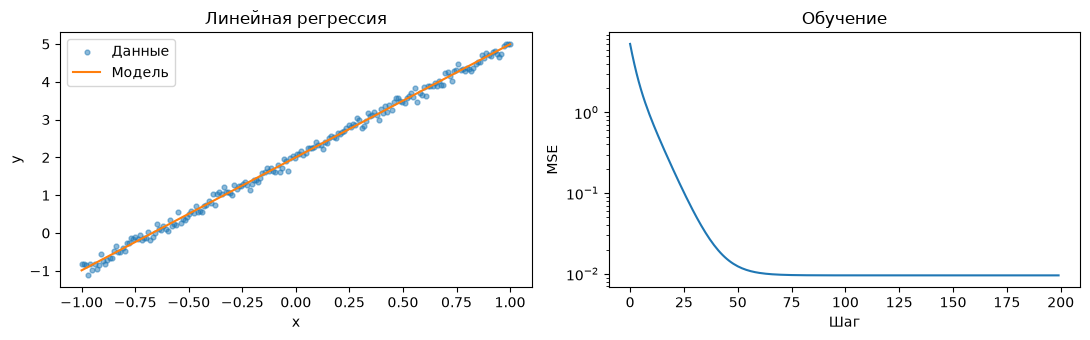

w=2.992, b=2.005, MSE=0.0096


In [ ]:
regression_losses = []
for step in range(200):
    w.grad = None
    b.grad = None
    prediction = w * x_reg + b
    loss = F.mse_loss(prediction, y_reg)
    loss.backward()
    with torch.no_grad():
        w -= 0.1 * w.grad
        b -= 0.1 * b.grad
    regression_losses.append(loss.item())

with torch.no_grad():
    fitted = w * x_reg + b
    final_regression_loss = F.mse_loss(fitted, y_reg).item()
assert final_regression_loss < 0.03
assert abs(w.item() - 3.0) < 0.1 and abs(b.item() - 2.0) < 0.1
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].scatter(x_reg.numpy(), y_reg.numpy(), s=12, alpha=0.5, label="Данные")
axes[0].plot(x_reg.numpy(), fitted.numpy(), color="tab:orange", label="Модель")
axes[0].set(xlabel="x", ylabel="y", title="Линейная регрессия")
axes[0].legend()
axes[1].semilogy(regression_losses)
axes[1].set(xlabel="Шаг", ylabel="MSE", title="Обучение")
plt.tight_layout()
plt.show()
print(f"w={w.item():.3f}, b={b.item():.3f}, MSE={final_regression_loss:.4f}")


### 3.3. Та же задача через nn.Linear и оптимизатор

`nn.Linear(1, 1)` хранит обучаемые `weight` и `bias` как `nn.Parameter`.
Оптимизатор получает ссылки на параметры и обновляет их при `step()`.
Порядок: **zero_grad - forward - loss - backward - step**.


In [ ]:
torch.manual_seed(SEED)
linear = nn.Linear(1, 1)
reg_optimizer = torch.optim.SGD(linear.parameters(), lr=0.1)
for step in range(200):
    reg_optimizer.zero_grad(set_to_none=True)
    predicted = linear(x_reg.unsqueeze(-1)).squeeze(-1)
    reg_loss = F.mse_loss(predicted, y_reg)
    reg_loss.backward()
    reg_optimizer.step()
with torch.no_grad():
    torch.testing.assert_close(linear(x_reg[:, None]).squeeze(-1), fitted, atol=1e-4, rtol=1e-4)
print("nn.Linear:", {name: p.detach().tolist() for name, p in linear.named_parameters()})


nn.Linear: {'weight': [[2.9915034770965576]], 'bias': [2.0045955181121826]}


## 4. Dataset, DataLoader и первая нейросеть

`Dataset` описывает доступ к одному объекту; `DataLoader` собирает объекты в батчи,
перемешивает индексы и при необходимости распараллеливает чтение.
Для уже готовых тензоров достаточно `TensorDataset`. Свой класс нужен, например,
для чтения файлов, преобразований или словаря с несколькими входами.

У map-style Dataset реализуют `__len__` и `__getitem__`; `__init__` задаёт нужное состояние.
Преобразуем весь массив в тензор один раз, а не будем копировать каждый объект при каждом чтении.


In [ ]:
class RegressionDataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.as_tensor(features, dtype=torch.float32)
        self.targets = torch.as_tensor(targets, dtype=torch.float32)
        if len(self.features) != len(self.targets):
            raise ValueError("Количество объектов и целей должно совпадать")

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return {"sample": self.features[index], "target": self.targets[index]}

toy_generator = torch.Generator().manual_seed(SEED)
toy_x = torch.randn(100, 5, generator=toy_generator)
toy_y = toy_x.sum(dim=1) + 0.1 * torch.randn(100, generator=toy_generator)
toy_dataset = RegressionDataset(toy_x, toy_y)
toy_loader = DataLoader(toy_dataset, batch_size=16, shuffle=True, num_workers=0,
                        generator=torch.Generator().manual_seed(SEED))
batch = next(iter(toy_loader))
assert batch["sample"].shape == (16, 5)
assert batch["target"].shape == (16,)
print({key: (value.shape, value.dtype) for key, value in batch.items()})
tensor_dataset = TensorDataset(toy_x, toy_y)
torch.testing.assert_close(tensor_dataset[0][0], toy_dataset[0]["sample"])


{'sample': (torch.Size([16, 5]), torch.float32), 'target': (torch.Size([16]), torch.float32)}


`num_workers=0` подходит для ноутбука и небольшого датасета.
 `shuffle=True` нужен для train, а для validation/test обычно используется `False`. Последний батч может быть меньше остальных.

### nn.Sequential и nn.Module

`Sequential` удобен для цепочки слоёв, а собственный `nn.Module` для более гибкого `forward`.
`nn.Linear` преобразует последнюю ось.

In [ ]:
toy_model = nn.Sequential(nn.Linear(5, 32), nn.ReLU(), nn.Linear(32, 1))
toy_prediction = toy_model(batch["sample"]).squeeze(-1)
assert toy_prediction.shape == batch["target"].shape
print(toy_model)
print("MSE до обучения:", F.mse_loss(toy_prediction, batch["target"]).item())


Sequential(
  (0): Linear(in_features=5, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=1, bias=True)
)
MSE до обучения: 5.009725570678711


## 5. Классификация рукописных цифр MNIST

### 5.1. Разделение данных

MNIST содержит изображения `[1, 28, 28]` и классы 0–9. Преобразуем интенсивности из целых
чисел 0–255 в `float32` в диапазоне [0, 1] с помощью `ToTensor`.

Из официальной обучающей выборки выделяем validation. **Test не используем для выбора
эпохи или гиперпараметров**; он нужен для итоговой оценки.


train=12000, validation=2000, test=10000


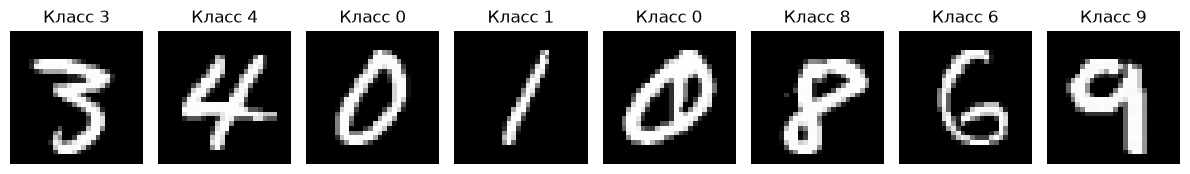

In [ ]:
transform = torchvision.transforms.ToTensor()
mnist_train_full = torchvision.datasets.MNIST(DATA_DIR, train=True, download=True, transform=transform)
mnist_test = torchvision.datasets.MNIST(DATA_DIR, train=False, download=True, transform=transform)
n_train, n_val = (12_000, 2_000) if QUICK_RUN else (55_000, 5_000)
train_dataset, val_dataset, unused_dataset = random_split(
    mnist_train_full,
    [n_train, n_val, len(mnist_train_full) - n_train - n_val],
    generator=torch.Generator().manual_seed(SEED),
)
assert set(train_dataset.indices).isdisjoint(val_dataset.indices)
BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
                          generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(mnist_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"train={len(train_dataset)}, validation={len(val_dataset)}, test={len(mnist_test)}")
images, targets = next(iter(train_loader))
assert images.shape[1:] == (1, 28, 28) and images.dtype == torch.float32
assert targets.dtype == torch.long and targets.min() >= 0 and targets.max() < 10
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, picture, label in zip(axes, images[:8], targets[:8]):
    ax.imshow(picture.squeeze(0), cmap="gray")
    ax.set_title(f"Класс {label.item()}")
    ax.axis("off")
plt.tight_layout()
plt.show()


### 5.2. Модель и функция потерь

Путь шейпов: `[B, 1, 28, 28] - [B, 784] - [B, 128] - [B, 10]`.
Выходы модели, **логиты**, произвольные вещественные оценки классов.
`CrossEntropyLoss` уже включает log-softmax, поэтому `Softmax` перед loss не нужен.
Цель для этого примера: `long` тензор `[B]`, содержащий индексы классов.
Вероятности для показа пользователю получаем отдельно через `logits.softmax(dim=1)`.

Модель переносим на устройство **до** создания оптимизатора. Входы и цели каждого батча
тоже переносим. Ускоритель не обязательно быстрее CPU на маленькой модели:
накладные расходы могут оказаться существенными.

In [ ]:
class DigitMLP(nn.Module):
    def __init__(self, hidden_size=128):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 10),
        )

    def forward(self, images):
        return self.layers(images)

torch.manual_seed(SEED)
model = DigitMLP().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()
with torch.no_grad():
    logits = model(images.to(device))
assert logits.shape == (len(images), 10)
print(model)
print("Обучаемых параметров:", sum(p.numel() for p in model.parameters() if p.requires_grad))
for name, parameter in model.named_parameters():
    print(name, tuple(parameter.shape), parameter.device)


DigitMLP(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)
Обучаемых параметров: 101770
layers.1.weight (128, 784) cpu
layers.1.bias (128,) cpu
layers.3.weight (10, 128) cpu
layers.3.bias (10,) cpu


### 5.3. Цикл обучения и корректные метрики

`model.train()` / `model.eval()` переключают поведение слоёв, например Dropout и BatchNorm
(подробнее на следующем семинаре). Они **не отключают autograd**.
Для оценки отдельно используем `torch.inference_mode()`. Не забываем `no_grad()`.

Loss каждого батча усреднён по его объектам. Для среднего по датасету умножаем его на размер
батча, складываем и делим на общее число объектов: последний батч может быть неполным.
Accuracy — доля верно предсказанных классов. Train-метрики ниже измеряются по ходу обновления весов,
validation — после эпохи, поэтому они не полностью симметричны.


In [ ]:
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    loss_sum, correct, count = 0.0, 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(inputs)
        loss = loss_fn(logits, targets)
        if not torch.isfinite(loss):
            raise RuntimeError("Loss стал NaN/Inf: проверьте данные и learning rate")
        loss.backward()
        optimizer.step()
        size = targets.size(0)
        loss_sum += loss.item() * size
        correct += (logits.argmax(dim=1) == targets).sum().item()
        count += size
    return {"loss": loss_sum / count, "accuracy": correct / count}


@torch.inference_mode()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    loss_sum, correct, count = 0.0, 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        logits = model(inputs)
        size = targets.size(0)
        loss_sum += loss_fn(logits, targets).item() * size
        correct += (logits.argmax(dim=1) == targets).sum().item()
        count += size
    return {"loss": loss_sum / count, "accuracy": correct / count}


In [ ]:
# Проверка усреднения на трёх объектах: батчи имеют размеры 2 и 1.
check_logits = torch.tensor([[4.0, 0.0], [0.0, 4.0], [3.0, 0.0]])
check_targets = torch.tensor([0, 1, 1])
check_loader = DataLoader(TensorDataset(check_logits, check_targets), batch_size=2)
check_metrics = evaluate(nn.Identity(), check_loader, loss_fn, torch.device("cpu"))
assert abs(check_metrics["loss"] - loss_fn(check_logits, check_targets).item()) < 1e-6
assert check_metrics["accuracy"] == 2 / 3
print("Проверка метрик на неполном батче пройдена.")


Проверка метрик на неполном батче пройдена.


In [ ]:
EPOCHS = 3 if QUICK_RUN else 5
history = []
initial_val = evaluate(model, val_loader, loss_fn, device)
best_val_loss = float("inf")
best_state = None
best_epoch = None
print(f"До обучения: val_loss={initial_val['loss']:.4f}, val_accuracy={initial_val['accuracy']:.2%}")
for epoch in range(1, EPOCHS + 1):
    train_metrics = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
    val_metrics = evaluate(model, val_loader, loss_fn, device)
    history.append({"epoch": epoch, "train_loss": train_metrics["loss"],
                    "train_accuracy": train_metrics["accuracy"],
                    "val_loss": val_metrics["loss"], "val_accuracy": val_metrics["accuracy"]})
    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_epoch = epoch
        # clone нужен: state_dict без копии продолжал бы меняться при обучении.
        best_state = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}
    print(f"Epoch {epoch}/{EPOCHS}: train_loss={train_metrics['loss']:.4f}, "
          f"val_loss={val_metrics['loss']:.4f}, val_accuracy={val_metrics['accuracy']:.2%}")

assert best_val_loss < initial_val["loss"], "Validation loss не уменьшился"
assert max(row["val_accuracy"] for row in history) > 0.85, "Проверьте обучение классификатора"
model.load_state_dict(best_state)
print(f"Восстановлены веса эпохи {best_epoch}, выбранной по validation loss.")


До обучения: val_loss=2.2980, val_accuracy=10.15%


Epoch 1/3: train_loss=0.8597, val_loss=0.3935, val_accuracy=89.30%


Epoch 2/3: train_loss=0.3434, val_loss=0.3116, val_accuracy=91.45%


Epoch 3/3: train_loss=0.2793, val_loss=0.2834, val_accuracy=92.00%
Восстановлены веса эпохи 3, выбранной по validation loss.


Порог accuracy 85% — проверка работоспособности стандартного запуска, а не критерий подбора модели.
Если вы намеренно меняете число эпох, объём данных или архитектуру в экспериментах, пересмотрите проверку.


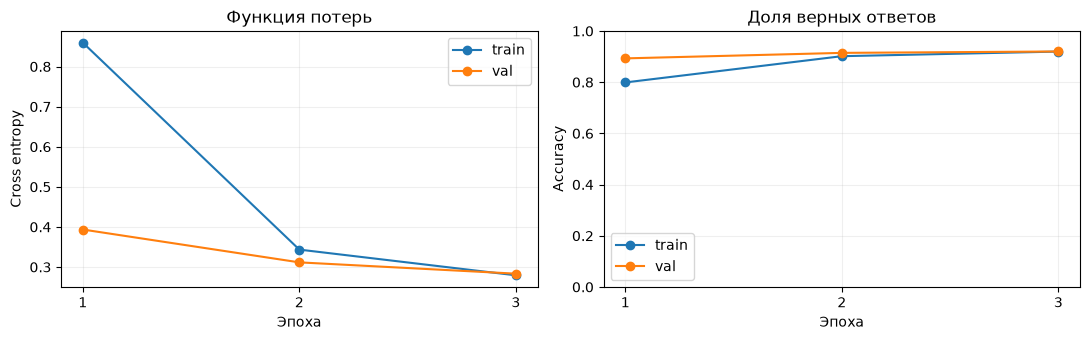

In [ ]:
epochs = [row["epoch"] for row in history]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for split in ("train", "val"):
    axes[0].plot(epochs, [row[f"{split}_loss"] for row in history], marker="o", label=split)
    axes[1].plot(epochs, [row[f"{split}_accuracy"] for row in history], marker="o", label=split)
axes[0].set(xlabel="Эпоха", ylabel="Cross entropy", title="Функция потерь", xticks=epochs)
axes[1].set(xlabel="Эпоха", ylabel="Accuracy", title="Доля верных ответов", xticks=epochs, ylim=(0, 1))
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


Если train loss уменьшается, а validation loss начинает расти, возможное объяснение — переобучение.
Сравните кривые и попробуйте изменить размер сети, количество данных или регуляризацию.
W&B / TensorBoard можно подключить позже: для первого эксперимента достаточно таблицы `history` и графиков.


### 5.4. Итоговая оценка и разбор ошибок

Оцениваем выбранную модель на test один раз. Матрица ошибок показывает, какие классы путаются:
строки — истинная цифра, столбцы — предсказанная.


Test: loss=0.2824, accuracy=91.89%


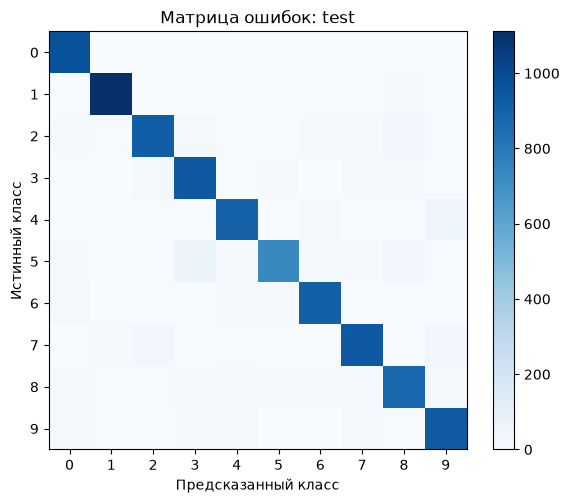

In [ ]:
test_metrics = evaluate(model, test_loader, loss_fn, device)
print(f"Test: loss={test_metrics['loss']:.4f}, accuracy={test_metrics['accuracy']:.2%}")
all_predictions, all_targets = [], []
with torch.inference_mode():
    for inputs, targets in test_loader:
        all_predictions.append(model(inputs.to(device)).argmax(dim=1).cpu())
        all_targets.append(targets)
test_predictions = torch.cat(all_predictions)
test_targets = torch.cat(all_targets)
confusion = torch.bincount(10 * test_targets + test_predictions, minlength=100).reshape(10, 10)
assert confusion.sum().item() == len(mnist_test)
assert abs(confusion.diag().sum().item() / len(mnist_test) - test_metrics["accuracy"]) < 1e-12
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(confusion.numpy(), cmap="Blues")
ax.set(xlabel="Предсказанный класс", ylabel="Истинный класс", title="Матрица ошибок: test",
       xticks=range(10), yticks=range(10))
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


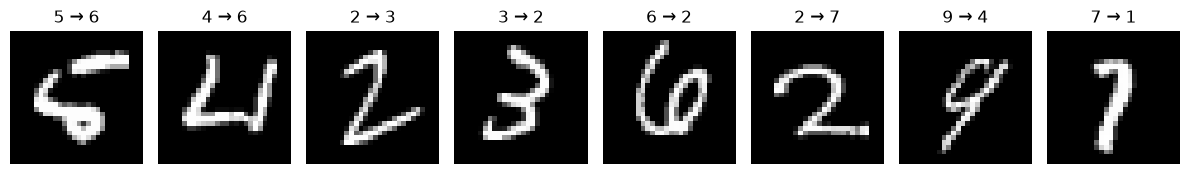

In [ ]:
wrong_indices = (test_predictions != test_targets).nonzero(as_tuple=True)[0][:8]
if len(wrong_indices):
    fig, axes = plt.subplots(1, len(wrong_indices), figsize=(12, 2), squeeze=False)
    for ax, index in zip(axes[0], wrong_indices.tolist()):
        picture, label = mnist_test[index]
        ax.imshow(picture.squeeze(0), cmap="gray")
        ax.set_title(f"{label} → {test_predictions[index].item()}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("На тестовой выборке ошибок нет.")


## 6. Сохранение и загрузка модели

Сохраняем `state_dict` и параметры архитектуры. Загружаем на CPU через `map_location`, затем
переносим модель на нужное устройство. `weights_only=True` ограничивает десериализацию.

Для продолжения обучения дополнительно понадобятся состояние оптимизатора, номер эпохи
и состояния генераторов случайных чисел. Здесь сохраняем модель для предсказаний.

In [ ]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
checkpoint_path = ARTIFACT_DIR / "mnist_mlp.pt"
torch.save({"model_state": best_state, "hidden_size": 128, "seed": SEED,
            "best_epoch": best_epoch, "input_shape": [1, 28, 28]}, checkpoint_path)
checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=True)
restored_model = DigitMLP(hidden_size=checkpoint["hidden_size"])
restored_model.load_state_dict(checkpoint["model_state"])
restored_model = restored_model.to(device)
restored_model.eval()
model.eval()
sample_images, sample_labels = next(iter(test_loader))
with torch.inference_mode():
    reference_logits = model(sample_images.to(device))
    restored_logits = restored_model(sample_images.to(device))
    torch.testing.assert_close(reference_logits, restored_logits)
    probabilities = restored_logits.softmax(dim=1).cpu()
torch.testing.assert_close(probabilities.sum(dim=1), torch.ones(len(probabilities)))
print("Предсказания до/после сохранения совпали:", checkpoint_path)
print("Первая цифра:", sample_labels[0].item(), "предсказание:", probabilities[0].argmax().item())
print("Вероятности:", probabilities[0].numpy().round(3))


Предсказания до/после сохранения совпали: artifacts/mnist_mlp.pt
Первая цифра: 7 предсказание: 7
Вероятности: [0.    0.    0.    0.002 0.    0.    0.    0.996 0.    0.001]


## Дополнительные материалы

- [PyTorch: Learn the Basics](https://docs.pytorch.org/tutorials/beginner/basics/intro.html)
- [Тензоры и общая память с NumPy](https://docs.pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html)
- [Autograd](https://docs.pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html)
- [Цикл оптимизации](https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html)
- [Сохранение и загрузка](https://docs.pytorch.org/tutorials/beginner/basics/saveloadrun_tutorial.html)
- [Воспроизводимость](https://docs.pytorch.org/docs/stable/notes/randomness.html)